## Seminar 2: ALS

In [1]:
!pip install implicit==0.7.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.1-cp312-cp312-linux_x86_64.whl size=10854922 sha256=27713f0b75dee96e004d5d8ad89ecb5d8c9e7eae1ebeb7389af2348acb0832f8
  Stored in directory: /root/.cache/pip/wheels/31/7c/16/2fc2d7f40d965fec18daf8c0524d7695e756c040fd42e4d316
Successfully built implicit


In [25]:
!pip install numpy==1.24.3

  Using cached numpy-1.24.3.tar.gz (10.9 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [4]:
import os
import time
from typing import List, Tuple

import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
import polars as pl
import numpy as np
import scipy.sparse as sp
import seaborn as sns
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import mean_average_precision_at_k
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:13: UserWarning: CUDA extension is built, but disabling GPU support because of 'Cuda Error: CUDA driver version is insufficient for CUDA runtime version (/tmp/pip-install-uczynh21/implicit_068a8bbc74cc411b9b53581946c0c356/./implicit/gpu/utils.h:71)'
  warnings.warn(


### 1. Download dataset

The data used in this seminar can be downloaded from

https://huggingface.co/datasets/deepvk/VK-LSVD

We will use VK-LSVD Dataset, which short-video recommendations (like Tik-Tok).

In [6]:
subsample_name = 'up0.001_ip0.001'
content_embedding_size = 32

train_interactions_files = [f'subsamples/{subsample_name}/train/week_{i:02}.parquet'
                            for i in range(25)]
val_interactions_file = [f'subsamples/{subsample_name}/validation/week_25.parquet']

metadata_files = ['metadata/users_metadata.parquet',
                  'metadata/items_metadata.parquet',
                  'metadata/item_embeddings.npz']

for file in (train_interactions_files +
             val_interactions_file +
             metadata_files):
    hf_hub_download(
        repo_id='deepvk/VK-LSVD', repo_type='dataset',
        filename=file, local_dir='VK-LSVD'
    )

train_interactions = pl.concat([pl.scan_parquet(f'VK-LSVD/{file}')
                                for file in train_interactions_files])
train_interactions = train_interactions.collect(engine='streaming')

val_interactions = pl.read_parquet(f'VK-LSVD/{val_interactions_file[0]}')

train_users = train_interactions.select('user_id').unique()
train_items = train_interactions.select('item_id').unique()

item_ids = np.load('VK-LSVD/metadata/item_embeddings.npz')['item_id']
item_embeddings = np.load('VK-LSVD/metadata/item_embeddings.npz')['embedding']

mask = np.isin(item_ids, train_items.to_numpy())
item_ids = item_ids[mask]
item_embeddings = item_embeddings[mask]
item_embeddings = item_embeddings[:, :content_embedding_size]

users_metadata = pl.read_parquet('VK-LSVD/metadata/users_metadata.parquet')
items_metadata = pl.read_parquet('VK-LSVD/metadata/items_metadata.parquet')

users_metadata = users_metadata.join(train_users, on='user_id')
items_metadata = items_metadata.join(train_items, on='item_id')
items_metadata = items_metadata.join(pl.DataFrame({'item_id': item_ids,
                                                   'embedding': item_embeddings}),
                                     on='item_id')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


subsamples/up0.001_ip0.001/train/week_00(…):   0%|          | 0.00/3.02M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/train/week_01(…):   0%|          | 0.00/4.60M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/train/week_02(…):   0%|          | 0.00/5.71M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/train/week_03(…):   0%|          | 0.00/6.01M [00:00<?, ?B/s]

...

subsamples/up0.001_ip0.001/train/week_24(…):   0%|          | 0.00/6.12M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/validation/we(…):   0%|          | 0.00/2.62M [00:00<?, ?B/s]

metadata/users_metadata.parquet:   0%|          | 0.00/72.5M [00:00<?, ?B/s]

metadata/items_metadata.parquet:   0%|          | 0.00/156M [00:00<?, ?B/s]

metadata/item_embeddings.npz:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

### 2. EDA

In [ ]:
train_interactions.head()

user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,click_on_author,open_comments
u32,u32,u8,u8,u8,u8,bool,bool,bool,bool,bool,bool
141827770,160593626,1,1,1,56,false,false,false,false,false,false
468779351,327484273,1,0,0,1,false,false,false,false,false,false
494341617,402842289,1,0,0,11,false,false,false,false,false,false
453833313,102672169,0,0,0,45,false,false,false,false,false,false
154047442,139795075,1,0,0,39,false,false,false,false,false,false


In [51]:
items_metadata.head()

item_id,author_id,duration,train_interactions_rank,embedding
u32,u32,u8,u32,"array[f32, 32]"
66761,451170,92,11105,"[-0.53418, -0.093689, … 0.083801]"
71482,421359,14,19098,"[-0.548828, 0.061951, … 0.110901]"
99494,396985,7,10228,"[-0.571777, 0.30249, … 0.128784]"
150686,674084,33,6408,"[-0.176025, -0.343506, … 0.093628]"
182273,882856,32,14982,"[-0.21875, 0.160278, … 0.203369]"


In [7]:
print("Dataset Shape:", train_interactions.shape)
print("\nBasic Info:")
print(train_interactions.schema)
print("\nDescriptive Statistics:")
print(train_interactions.describe())

Dataset Shape: (47068641, 12)

Basic Info:
Schema({'user_id': UInt32, 'item_id': UInt32, 'place': UInt8, 'platform': UInt8, 'agent': UInt8, 'timespent': UInt8, 'like': Boolean, 'dislike': Boolean, 'share': Boolean, 'bookmark': Boolean, 'click_on_author': Boolean, 'open_comments': Boolean})

Descriptive Statistics:
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ user_id   ┆ item_id   ┆ place     ┆ … ┆ share     ┆ bookmark  ┆ click_on_ ┆ open_com │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ author    ┆ ments    │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 4.7068641 ┆ 4.7068641 ┆ 4.7068641 ┆ … ┆ 4.7068641

/tmp/ipython-input-591099230.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  user_interaction_counts = train_interactions.group_by('user_id').agg(pl.count().alias('interaction_count')).sort('interaction_count', descending=True)


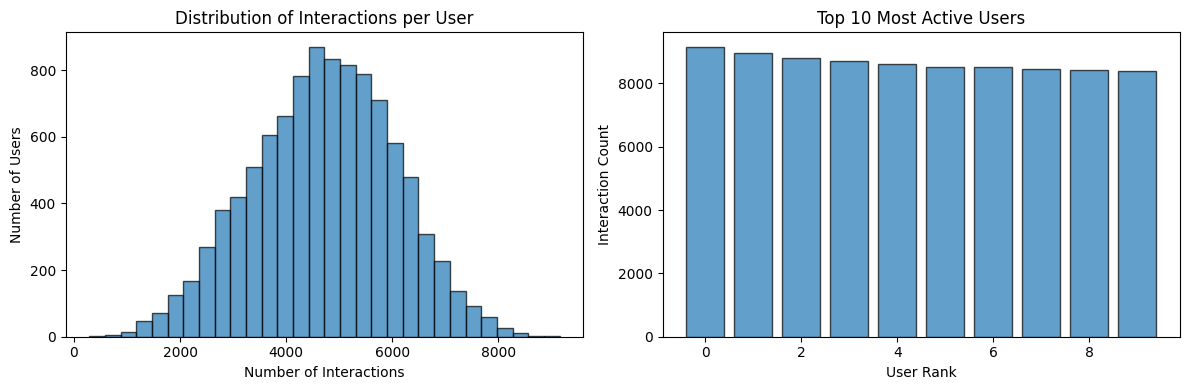

Total unique users: 10000
Average interactions per user: 4706.86


In [12]:
user_interaction_counts = train_interactions.group_by('user_id').agg(pl.count().alias('interaction_count')).sort('interaction_count', descending=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
interaction_counts = user_interaction_counts['interaction_count'].to_list()
plt.hist(interaction_counts, bins=30, alpha=0.7, edgecolor='black')
plt.title('Distribution of interactions per user')
plt.xlabel('Number of interactions')
plt.ylabel('Number of users')

plt.subplot(1, 2, 2)
top_users = user_interaction_counts.head(10)
plt.bar(range(len(top_users)), top_users['interaction_count'].to_list(), alpha=0.7, edgecolor='black')
plt.title('Top 10 most active users')
plt.xlabel('User rank')
plt.ylabel('Interaction count')

plt.tight_layout()
plt.show()

print(f"Total unique users: {train_interactions['user_id'].n_unique()}")
print(f"Average interactions per user: {user_interaction_counts['interaction_count'].mean():.2f}")

/tmp/ipython-input-2834208555.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  item_interaction_counts = train_interactions.group_by('item_id').agg(pl.count().alias('interaction_count')).sort('interaction_count', descending=True)


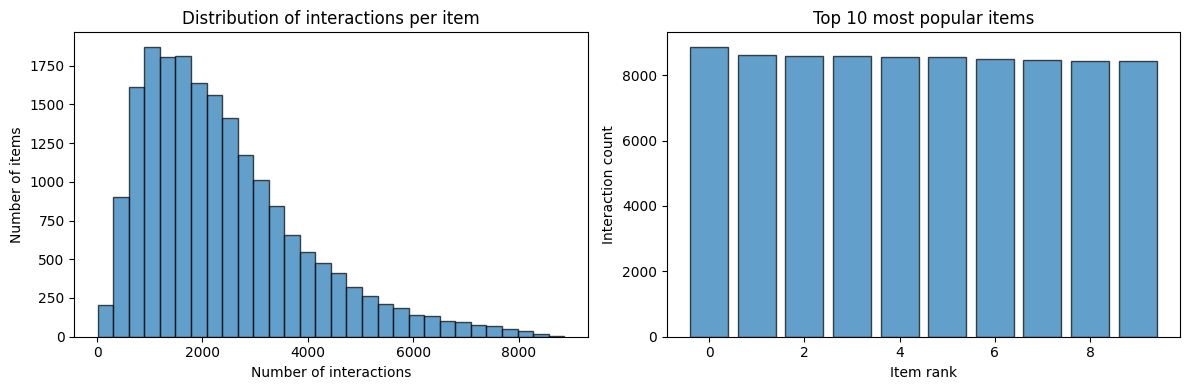

Total unique items: 19628
Average interactions per item: 2398.04


In [13]:
item_interaction_counts = train_interactions.group_by('item_id').agg(pl.count().alias('interaction_count')).sort('interaction_count', descending=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
interaction_counts = item_interaction_counts['interaction_count'].to_list()
plt.hist(interaction_counts, bins=30, alpha=0.7, edgecolor='black')
plt.title('Distribution of interactions per item')
plt.xlabel('Number of interactions')
plt.ylabel('Number of items')

plt.subplot(1, 2, 2)
top_items = item_interaction_counts.head(10)
plt.bar(range(len(top_items)), top_items['interaction_count'].to_list(), alpha=0.7, edgecolor='black')
plt.title('Top 10 most popular items')
plt.xlabel('Item rank')
plt.ylabel('Interaction count')

plt.tight_layout()
plt.show()

print(f"Total unique items: {train_interactions['item_id'].n_unique()}")
print(f"Average interactions per item: {item_interaction_counts['interaction_count'].mean():.2f}")

Let's also preprocess dataset for ALS using scipy sparse matrices:

In [42]:
import polars as pl
import implicit
import numpy as np
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

def create_mappings(df):
    user_ids = df['user_id'].unique().sort()
    item_ids = df['item_id'].unique().sort()

    # Create mapping dictionaries
    user_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
    item_to_index = {item_id: idx for idx, item_id in enumerate(item_ids)}

    # Reverse mappings for converting back
    index_to_user = {idx: user_id for user_id, idx in user_to_index.items()}
    index_to_item = {idx: item_id for item_id, idx in item_to_index.items()}

    return user_to_index, item_to_index, index_to_user, index_to_item

def prepare_als_positive_only(df):
    # Filter only positive interactions
    positive_df = df.filter(pl.col('like') == True)

    user_to_index, item_to_index, index_to_user, index_to_item = create_mappings(df)

    positive_df = positive_df.with_columns([
        pl.col('user_id').replace(user_to_index, default=None).alias('user_idx'),
        pl.col('item_id').replace(item_to_index, default=None).alias('item_idx')
    ])

    positive_df = positive_df.filter(
        pl.col('user_idx').is_not_null() & pl.col('item_idx').is_not_null()
    )

    # Create sparse matrix with binary feedback (1 for likes)
    user_indices = positive_df['user_idx'].cast(pl.Int32).to_list()
    item_indices = positive_df['item_idx'].cast(pl.Int32).to_list()
    data = np.ones(len(user_indices))

    n_users = len(user_to_index)
    n_items = len(item_to_index)

    sparse_matrix = csr_matrix(
        (data, (user_indices, item_indices)),
        shape=(n_users, n_items)
    )

    return sparse_matrix, user_to_index, item_to_index, index_to_user, index_to_item

def prepare_als_ts(df):
    user_to_index, item_to_index, index_to_user, index_to_item = create_mappings(df)

    df = df.with_columns([
        pl.col('user_id').replace(user_to_index, default=None).alias('user_idx'),
        pl.col('item_id').replace(item_to_index, default=None).alias('item_idx')
    ])

    df = df.filter(
        pl.col('user_idx').is_not_null() & pl.col('item_idx').is_not_null()
    )

    # Create sparse matrix with binary feedback (1 for likes)
    user_indices = df['user_idx'].cast(pl.Int32).to_list()
    item_indices = df['item_idx'].cast(pl.Int32).to_list()
    data = np.ones(len(user_indices))

    n_users = len(user_to_index)
    n_items = len(item_to_index)

    sparse_matrix = csr_matrix(
        (data, (user_indices, item_indices)),
        shape=(n_users, n_items)
    )

    return sparse_matrix, user_to_index, item_to_index, index_to_user, index_to_item

## 3. Train

In [46]:
def train_als_model(sparse_matrix, factors=50, iterations=20, regularization=0.01):
    model = AlternatingLeastSquares(
        factors=factors,
        iterations=iterations,
        regularization=regularization,
        random_state=42
    )

    model.fit(sparse_matrix)
    return model

In [37]:
sparse_matrix, user_to_index, item_to_index, index_to_user, index_to_item = prepare_als_positive_only(train_interactions)

/tmp/ipython-input-336423995.py:28: DeprecationWarning: The `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
  pl.col('user_id').replace(user_to_index, default=None).alias('user_idx'),
/tmp/ipython-input-336423995.py:29: DeprecationWarning: The `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
  pl.col('item_id').replace(item_to_index, default=None).alias('item_idx')


In [38]:
model = train_als_model(sparse_matrix)

  0%|          | 0/100 [00:00<?, ?it/s]

In [43]:
sparse_matrix, user_to_index, item_to_index, index_to_user, index_to_item = prepare_als_ts(train_interactions)

/tmp/ipython-input-417218110.py:55: DeprecationWarning: The `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
  pl.col('user_id').replace(user_to_index, default=None).alias('user_idx'),
/tmp/ipython-input-417218110.py:56: DeprecationWarning: The `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
  pl.col('item_id').replace(item_to_index, default=None).alias('item_idx')


In [47]:
model = train_als_model(sparse_matrix)

  0%|          | 0/20 [00:00<?, ?it/s]

In [48]:
from sklearn.metrics import precision_score, recall_score, ndcg_score

def evaluate_model(model, val_df, user_to_index, item_to_index, index_to_item, k=10):
    val_positive = val_df.filter(pl.col('like') == True)

    val_positive = val_positive.filter(pl.col('item_id').is_in(list(item_to_index.keys())))

    actual_liked = (
        val_positive
        .group_by('user_id')
        .agg(pl.col('item_id'))
        .with_columns(pl.col('item_id').list.eval(pl.element().unique()))
    )

    user_actual_liked = {
        row['user_id']: set(row['item_id'])
        for row in actual_liked.iter_rows(named=True)
    }

    precisions = []
    recalls = []
    ndcgs = []
    users_evaluated = 0

    for user_id, actual_items in user_actual_liked.items():
        if user_id not in user_to_index:
            continue

        user_idx = user_to_index[user_id]

        try:
            item_indices, scores = model.recommend(
                userid=user_idx,
                user_items=sparse_matrix[user_idx],
                N=k,
                filter_already_liked_items=True
            )

            recommended_items = [index_to_item[idx] for idx in item_indices]

            precision, recall, ndcg = calculate_metrics(
                recommended_items, actual_items, k
            )

            precisions.append(precision)
            recalls.append(recall)
            ndcgs.append(ndcg)
            users_evaluated += 1

        except Exception as e:
            continue

    results = {
        'precision@k': np.mean(precisions) if precisions else 0,
        'recall@k': np.mean(recalls) if recalls else 0,
        'ndcg@k': np.mean(ndcgs) if ndcgs else 0,
        'users_evaluated': users_evaluated,
        'total_validation_users': len(user_actual_liked)
    }

    return results

def calculate_metrics(recommended, actual, k):
    top_k = set(recommended[:k])

    relevant_in_top_k = top_k.intersection(actual)

    precision = len(relevant_in_top_k) / k

    recall = len(relevant_in_top_k) / len(actual) if len(actual) > 0 else 0

    ndcg = calculate_ndcg(recommended, actual, k)

    return precision, recall, ndcg

def calculate_ndcg(recommended, actual, k):
    relevance = [1 if item in actual else 0 for item in recommended[:k]]

    dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevance)])

    ideal_relevance = [1] * min(len(actual), k)
    ideal_dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(ideal_relevance)])

    return dcg / ideal_dcg if ideal_dcg > 0 else 0

In [49]:
def run_complete_evaluation(model, train_df, val_df, k_values=[5, 10, 20]):
    user_to_index, item_to_index, index_to_user, index_to_item = create_mappings(train_df)

    print("=== Model Evaluation Results ===")
    print(f"Training users: {len(user_to_index)}")
    print(f"Training items: {len(item_to_index)}")
    print(f"Validation users with likes: {val_df.filter(pl.col('like') == True)['user_id'].n_unique()}")
    print()

    results = {}

    for k in k_values:
        print(f"--- Metrics @ K={k} ---")

        main_metrics = evaluate_model(model, val_df, user_to_index, item_to_index, index_to_item, k=k)
        results[k] = main_metrics

        print(f"Precision@{k}: {main_metrics['precision@k']:.4f}")
        print(f"Recall@{k}: {main_metrics['recall@k']:.4f}")
        print(f"NDCG@{k}: {main_metrics['ndcg@k']:.4f}")
        print(f"Users evaluated: {main_metrics['users_evaluated']}/{main_metrics['total_validation_users']}")
        print()

In [50]:
results = run_complete_evaluation(model, train_interactions, val_interactions, k_values=[5, 10, 20])

single_eval = evaluate_model(model, val_interactions, user_to_index, item_to_index, index_to_item, k=10)
print(f"Precision@10: {single_eval['precision@k']:.4f}")

=== Model Evaluation Results ===
Training users: 10000
Training items: 19628
Validation users with likes: 1526

--- Metrics @ K=5 ---
Precision@5: 0.0046
Recall@5: 0.0108
NDCG@5: 0.0094
Users evaluated: 1526/1526

--- Metrics @ K=10 ---
Precision@10: 0.0031
Recall@10: 0.0134
NDCG@10: 0.0102
Users evaluated: 1526/1526

--- Metrics @ K=20 ---
Precision@20: 0.0026
Recall@20: 0.0207
NDCG@20: 0.0125
Users evaluated: 1526/1526

Precision@10: 0.0031


Let's check data sparsity:

In [ ]:
total_possible_interactions = len(user_to_index) * len(item_to_index)
actual_interactions = sparse_matrix.nnz
sparsity = actual_interactions / total_possible_interactions
print(f"Data sparsity: {sparsity:.6f}")

avg_interactions = actual_interactions / len(user_to_index)
print(f"Avg interactions per user: {avg_interactions:.2f}")

Data sparsity: 0.002312
Avg interactions per user: 45.38
